# Modeling Human Activity States Using Hidden Markov Models

## Background and Motivation

Human Activity Recognition (HAR) is a critical application in ubiquitous computing with significant implications for healthcare monitoring, smart environments, and fitness tracking. Our project focuses on distinguishing between four distinct human activities: **Walking**, **Jumping**, **Standing**, and **Still (no movement)** using smartphone inertial sensors (accelerometer and gyroscope).

These activities represent different motion dynamics:
- **Walking**: Rhythmic, cyclical motion patterns
- **Jumping**: High-energy, vertical acceleration bursts
- **Standing**: Subtle micro-movements from body sway and breathing
- **Still**: Minimal to zero motion when the device is stationary

Hidden Markov Models (HMMs) are particularly well-suited for this sequential classification task as they can model temporal dependencies in sensor data and capture the stochastic nature of human movement patterns. Our unique use case focuses on creating a robust activity classifier that can distinguish between these four fundamental movement states for potential applications in health monitoring and motion analysis systems.

---

## 0. Setup and Imports

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

print('All imports successful!')

All imports successful!


## 1. Data Collection & Preprocessing

### 1.1 Extract Data from Zip Files

Our dataset contains 4 activity types recorded using the **Sensor Logger** app on two smartphones at different sampling rates (~100 Hz and ~50 Hz). Each recording captures both **accelerometer** (x, y, z) and **gyroscope** (x, y, z) data with nanosecond timestamps.

| Activity | Recordings | Approx. Sampling Rate | Total Duration |
|----------|------------|----------------------|----------------|
| Jumping  | 10         | ~100 Hz              | ~1 min 50 sec  |
| Walking  | 10         | ~100 Hz              | ~1 min 50 sec  |
| Standing | 13         | ~50 Hz               | ~2 min 22 sec  |
| Still    | 13         | ~50 Hz               | ~3 min 40 sec  |

**Total**: 46 paired sensor recordings (92 CSV files). Each activity exceeds the 1 minute 30 second minimum requirement.

In [2]:
# ============================================================
DATACOLLECT_DIR = "datacollect"  # folder containing all zip files
OUTPUT_DIR = "sensor_data"       # Extracted CSVs 
# ============================================================

NEEDED_FILES = ["Accelerometer.csv", "Gyroscope.csv"]

def extract_all_data():
    """Extract accelerometer and gyroscope data from all zip files."""
    
    # Create output directory if it doesn't exist
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    
    # Activity mapping based on filename patterns
    activity_patterns = {
        'jump': 'jumping',
        'walk': 'walking', 
        'standing': 'standing',
        'still': 'still'
    }
    
    extracted_count = 0
    
    # Process all zip files in datacollect directory
    for zip_filename in os.listdir(DATACOLLECT_DIR):
        if zip_filename.endswith('.zip'):
            zip_path = os.path.join(DATACOLLECT_DIR, zip_filename)
            
            # Determine activity type from filename
            activity_type = None
            for pattern, activity in activity_patterns.items():
                if zip_filename.lower().startswith(pattern):
                    activity_type = activity
                    break
            
            if activity_type is None:
                print(f"Warning: Could not determine activity type for {zip_filename}")
                continue
                
            # Extract files from zip
            try:
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    extracted_files = zip_ref.namelist()
                    
                    for needed_file in NEEDED_FILES:
                        if needed_file in extracted_files:
                            # Extract to activity-specific folder
                            activity_dir = os.path.join(OUTPUT_DIR, activity_type)
                            if not os.path.exists(activity_dir):
                                os.makedirs(activity_dir)
                            
                            # Create unique filename
                            base_name = os.path.splitext(zip_filename)[0]
                            sensor_name = os.path.splitext(needed_file)[0]
                            output_filename = f"{base_name}_{sensor_name}.csv"
                            output_path = os.path.join(activity_dir, output_filename)
                            
                            # Extract the file
                            with zip_ref.open(needed_file) as source, open(output_path, 'wb') as target:
                                target.write(source.read())
                        else:
                            print(f"Warning: {needed_file} not found in {zip_filename}")
                
                extracted_count += 1
                if extracted_count % 5 == 0:
                    print(f"Processed {extracted_count} zip files...")
                    
            except Exception as e:
                print(f"Error processing {zip_filename}: {e}")
    
    print(f"\nExtraction complete! Processed {extracted_count} zip files.")
    print(f"Data organized in '{OUTPUT_DIR}' directory by activity type.")

# Run the extraction
extract_all_data()

Processed 5 zip files...
Processed 10 zip files...
Processed 15 zip files...
Processed 20 zip files...
Processed 25 zip files...
Processed 30 zip files...
Processed 35 zip files...
Processed 40 zip files...
Processed 45 zip files...
Processed 50 zip files...

Extraction complete! Processed 50 zip files.
Data organized in 'sensor_data' directory by activity type.


### 1.2 Load and Merge Sensor Files

In [3]:
def load_recording_pair(acc_file: str, gyro_file: str) -> pd.DataFrame:
    """
    Load and merge accelerometer and gyroscope CSV files.
    Merges on nearest timestamp to handle slight timing differences.
    """
    acc  = pd.read_csv(acc_file)
    gyro = pd.read_csv(gyro_file)

    # Normalize column names to lowercase
    acc.columns  = [c.lower() for c in acc.columns]
    gyro.columns = [c.lower() for c in gyro.columns]

    # Rename sensor axes to avoid collision after merge
    acc  = acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
    gyro = gyro.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    # Sort by time
    acc  = acc.sort_values('time').reset_index(drop=True)
    gyro = gyro.sort_values('time').reset_index(drop=True)

    # Merge on nearest timestamp
    merged = pd.merge_asof(acc[['time','acc_x','acc_y','acc_z']],
                           gyro[['time','gyro_x','gyro_y','gyro_z']],
                           on='time', direction='nearest')
    merged = merged.dropna().reset_index(drop=True)
    return merged


def load_all_recordings(data_dir: str):
    """
    Load all recordings from sensor_data folder structure.
    Pairs accelerometer and gyroscope files by matching base names.
    Returns a dict: {activity_recording_name: dataframe}
    """
    recordings = {}
    
    # Process each activity folder
    for activity_folder in sorted(os.listdir(data_dir)):
        activity_path = os.path.join(data_dir, activity_folder)
        if not os.path.isdir(activity_path):
            continue
            
        print(f"\nProcessing {activity_folder} recordings:")
        
        # Get all CSV files in this activity folder
        csv_files = [f for f in os.listdir(activity_path) if f.endswith('.csv')]
        
        # Group accelerometer and gyroscope files by base name
        recording_pairs = {}
        for csv_file in csv_files:
            if '_Accelerometer.csv' in csv_file:
                base_name = csv_file.replace('_Accelerometer.csv', '')
                if base_name not in recording_pairs:
                    recording_pairs[base_name] = {}
                recording_pairs[base_name]['acc'] = os.path.join(activity_path, csv_file)
            elif '_Gyroscope.csv' in csv_file:
                base_name = csv_file.replace('_Gyroscope.csv', '')
                if base_name not in recording_pairs:
                    recording_pairs[base_name] = {}
                recording_pairs[base_name]['gyro'] = os.path.join(activity_path, csv_file)
        
        # Load each complete recording pair
        for base_name, files in recording_pairs.items():
            if 'acc' in files and 'gyro' in files:
                try:
                    df = load_recording_pair(files['acc'], files['gyro'])
                    recording_name = f"{activity_folder}_{base_name}"
                    recordings[recording_name] = df
                    print(f"  Loaded: {base_name:20s} | {len(df):5d} samples")
                except Exception as e:
                    print(f"  Skipped {base_name}: {e}")
            else:
                print(f"  Incomplete pair for {base_name} (missing acc or gyro file)")
    
    return recordings


# Load all recordings
recordings = load_all_recordings(OUTPUT_DIR)
print(f"\nTotal recordings loaded: {len(recordings)}")

# Show summary by activity
activity_counts = {}
for recording_name in recordings.keys():
    activity = recording_name.split('_')[0]
    activity_counts[activity] = activity_counts.get(activity, 0) + 1

print("\nRecordings per activity:")
for activity, count in sorted(activity_counts.items()):
    print(f"  {activity:10s}: {count:2d} recordings")


Processing jumping recordings:
  Loaded: jump1-2026-02-25_13-08-17 |  1084 samples
  Loaded: jump10-2026-02-25_13-11-32 |  1108 samples
  Loaded: jump11-2026-03-02_13-46-29 |  1178 samples
  Loaded: jump12-2026-03-02_13-46-43 |  1123 samples
  Loaded: jump2-2026-02-25_13-08-04 |  1114 samples
  Loaded: jump3-2026-02-25_13-09-19 |  1101 samples
  Loaded: jump4-2026-02-25_13-09-08 |  1074 samples
  Loaded: jump5-2026-02-25_13-09-50 |  1098 samples
  Loaded: jump6-2026-02-25_13-10-02 |  1110 samples
  Loaded: jump7-2026-02-25_13-10-33 |  1088 samples
  Loaded: jump8-2026-02-25_13-10-44 |  1114 samples
  Loaded: jump9-2026-02-25_13-11-20 |  1110 samples

Processing standing recordings:
  Loaded: standing_01          |   535 samples
  Loaded: standing_02          |   536 samples
  Loaded: standing_03          |   549 samples
  Loaded: standing_04          |   545 samples
  Loaded: standing_05          |   543 samples
  Loaded: standing_06          |   610 samples
  Loaded: standing_07     

### 1.3 Inspect Sampling Rate

In [4]:
def compute_sampling_rate(df: pd.DataFrame) -> float:
    """Estimate sampling rate in Hz from timestamp column."""
    times = df['time'].values
    # Sensor Logger timestamps may be in nanoseconds — convert if needed
    if times[0] > 1e10:   # nanoseconds
        times = times / 1e9
    diffs = np.diff(times)
    avg_interval = np.mean(diffs)
    return round(1.0 / avg_interval, 2)

print("Sampling rates per recording:")
print("-" * 40)
rates = {}
for name, df in recordings.items():
    sr = compute_sampling_rate(df)
    rates[name] = sr
    print(f"  {name:20s}: {sr} Hz")

# Use the most common sampling rate
all_rates = list(rates.values())
TARGET_SR = round(np.median(all_rates))
print(f"\nMedian sampling rate: {TARGET_SR} Hz  (used as TARGET_SR)")

Sampling rates per recording:
----------------------------------------
  jumping_jump1-2026-02-25_13-08-17: 100.03 Hz
  jumping_jump10-2026-02-25_13-11-32: 100.03 Hz
  jumping_jump11-2026-03-02_13-46-29: 100.03 Hz
  jumping_jump12-2026-03-02_13-46-43: 100.03 Hz
  jumping_jump2-2026-02-25_13-08-04: 100.03 Hz
  jumping_jump3-2026-02-25_13-09-19: 100.03 Hz
  jumping_jump4-2026-02-25_13-09-08: 100.03 Hz
  jumping_jump5-2026-02-25_13-09-50: 100.03 Hz
  jumping_jump6-2026-02-25_13-10-02: 100.03 Hz
  jumping_jump7-2026-02-25_13-10-33: 100.03 Hz
  jumping_jump8-2026-02-25_13-10-44: 100.03 Hz
  jumping_jump9-2026-02-25_13-11-20: 100.03 Hz
  standing_standing_01: 50.09 Hz
  standing_standing_02: 50.08 Hz
  standing_standing_03: 50.08 Hz
  standing_standing_04: 50.08 Hz
  standing_standing_05: 50.08 Hz
  standing_standing_06: 50.08 Hz
  standing_standing_07: 50.09 Hz
  standing_standing_08: 50.08 Hz
  standing_standing_09: 50.08 Hz
  standing_standing_10: 50.08 Hz
  standing_standing_11: 50.08 Hz

### 1.4 Visualize Raw Sensor Data

=== Raw Data Visualization ===

--- JUMPING ---
Plotting: jumping_jump1-2026-02-25_13-08-17


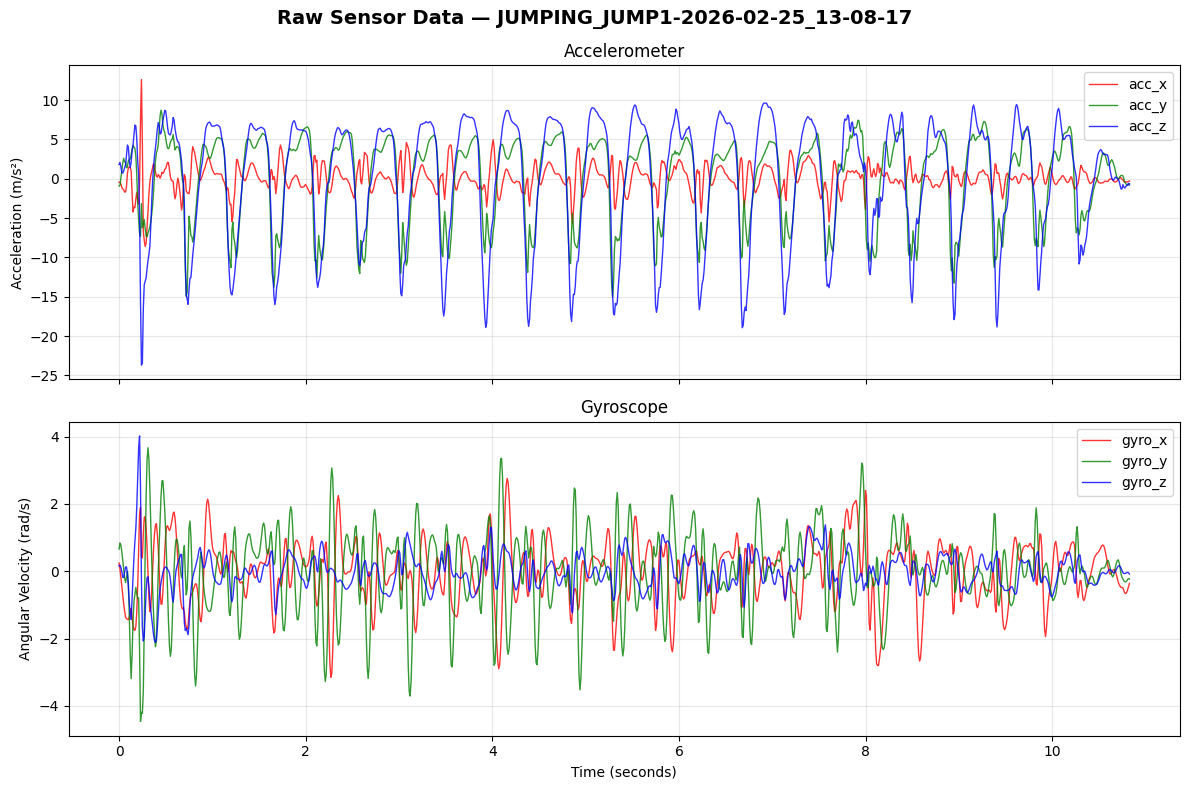


--- WALKING ---
Plotting: walking_walk1-2026-02-25_13-23-07


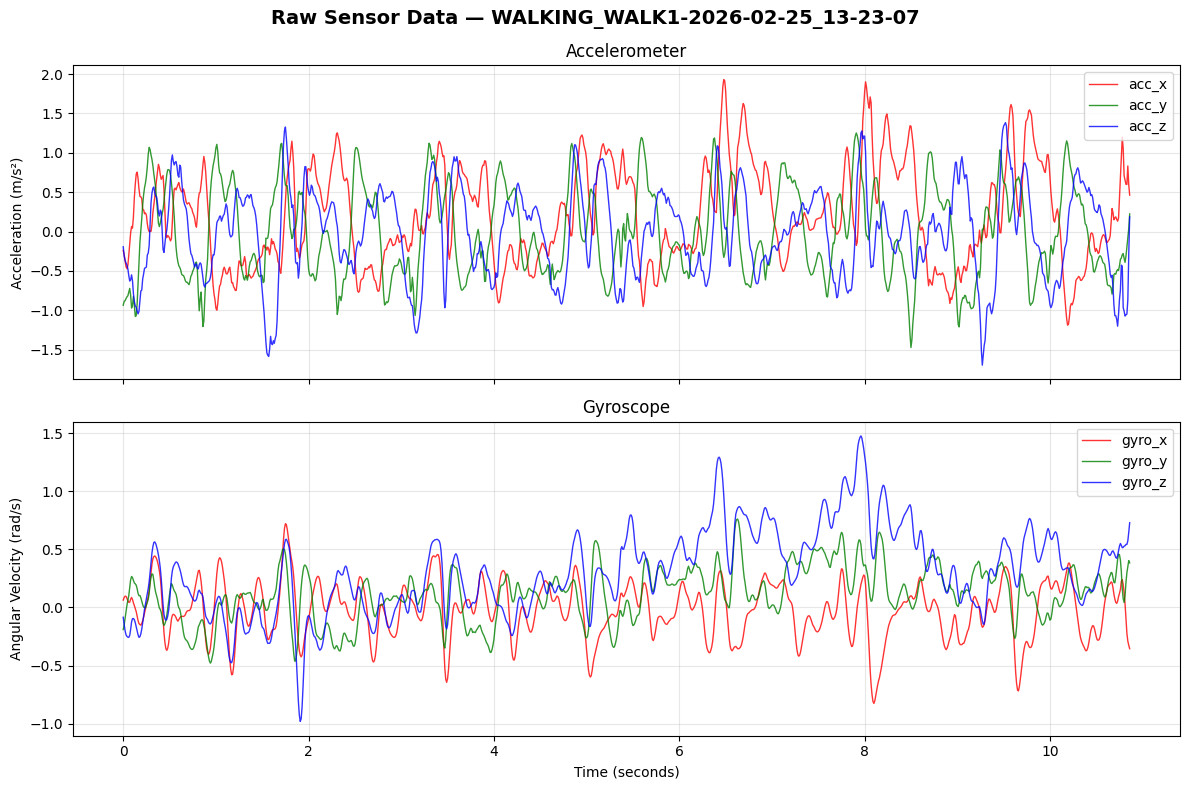


--- STANDING ---
Plotting: standing_standing_01


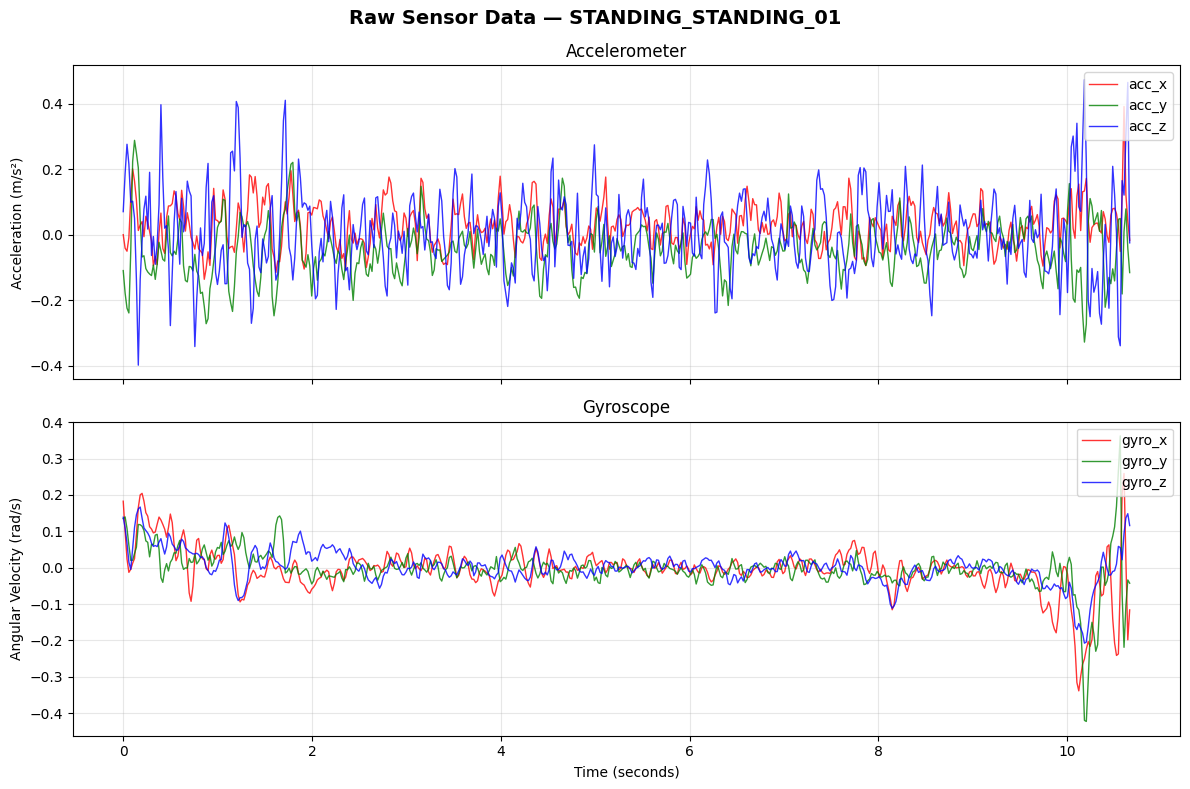


--- STILL ---
Plotting: still_still_01


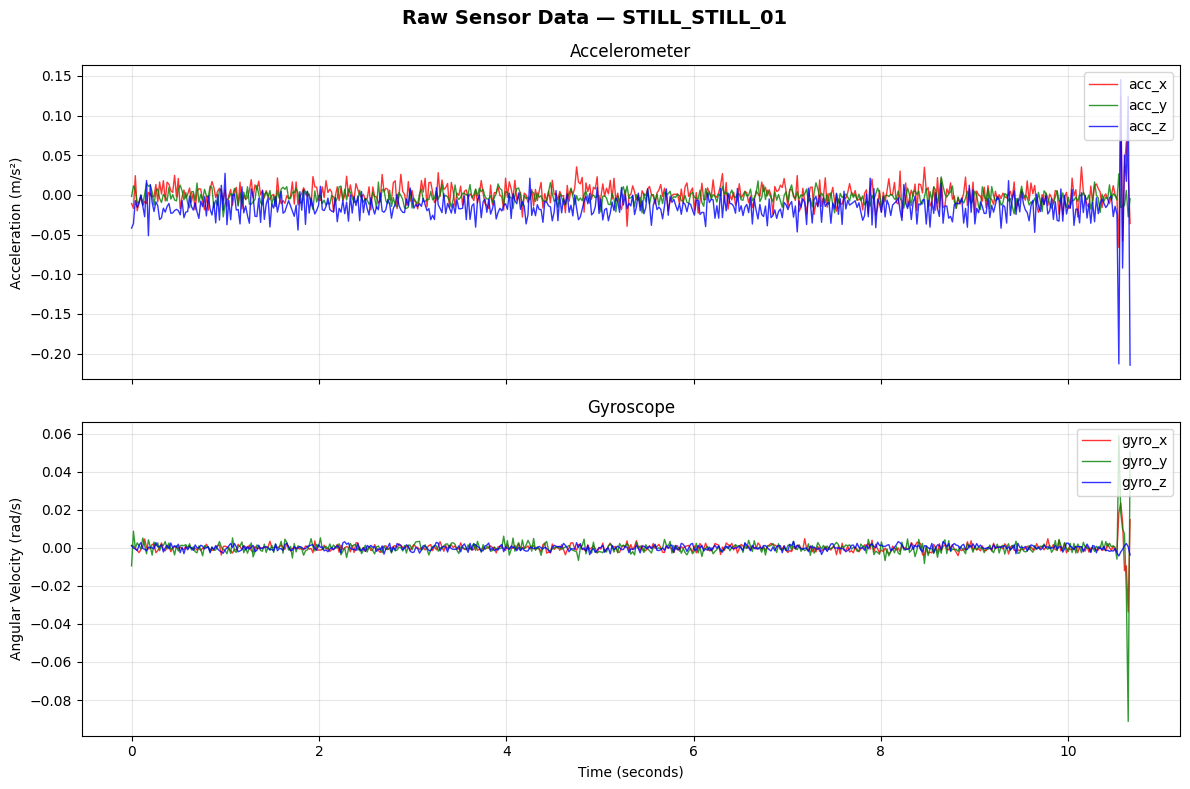

In [5]:
def plot_raw_sample(recordings: dict, activity: str, sample_index: int = 0):
    """Plot raw accelerometer and gyroscope signals for one recording."""
    
    # Find recordings for this activity
    activity_recordings = [k for k in recordings.keys() if k.startswith(activity)]
    
    if not activity_recordings:
        print(f"No recordings found for activity: {activity}")
        return
        
    if sample_index >= len(activity_recordings):
        print(f"Sample index {sample_index} not available. Activity '{activity}' has {len(activity_recordings)} recordings.")
        return
    
    # Get the specific recording
    recording_key = sorted(activity_recordings)[sample_index]
    df = recordings[recording_key].copy()
    
    print(f"Plotting: {recording_key}")

    # Normalize time to start from 0
    t = df['time'].values
    if t[0] > 1e10:
        t = t / 1e9
    t = t - t[0]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Raw Sensor Data — {recording_key.upper()}", fontsize=14, fontweight='bold')

    # Accelerometer
    axes[0].plot(t, df['acc_x'], label='acc_x', color='r', alpha=0.8, linewidth=1)
    axes[0].plot(t, df['acc_y'], label='acc_y', color='g', alpha=0.8, linewidth=1)
    axes[0].plot(t, df['acc_z'], label='acc_z', color='b', alpha=0.8, linewidth=1)
    axes[0].set_ylabel('Acceleration (m/s²)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Accelerometer')

    # Gyroscope
    axes[1].plot(t, df['gyro_x'], label='gyro_x', color='r', alpha=0.8, linewidth=1)
    axes[1].plot(t, df['gyro_y'], label='gyro_y', color='g', alpha=0.8, linewidth=1)
    axes[1].plot(t, df['gyro_z'], label='gyro_z', color='b', alpha=0.8, linewidth=1)
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('Gyroscope')

    plt.tight_layout()
    plt.show()

# Plot one sample per activity for visualization 
print("=== Raw Data Visualization ===")
activities = ['jumping', 'walking', 'standing', 'still']

for activity in activities:
    print(f"\n--- {activity.upper()} ---")
    plot_raw_sample(recordings, activity, 0)  # Plot first sample of each activity

## 2. Feature Extraction (Time-Domain + Frequency-Domain)

### Window Parameters

We use a sliding window approach. **Window size** is based on the sampling rate:
- At 50 Hz, a 2-second window = 100 samples → captures enough signal for FFT while keeping temporal resolution.
- 50% overlap (step = window_size // 2) increases the number of windows without data loss.

In [6]:
# Window parameters — based on sampling rate
WINDOW_SECONDS = 2          # 2-second window
WINDOW_SIZE    = int(TARGET_SR * WINDOW_SECONDS)   # e.g. 50Hz * 2s = 100 samples
STEP_SIZE      = WINDOW_SIZE // 2                  # 50% overlap

print(f"Window size : {WINDOW_SIZE} samples ({WINDOW_SECONDS}s at {TARGET_SR}Hz)")
print(f"Step size   : {STEP_SIZE} samples (50% overlap)")
print()
print("Justification: A 2-second window at 50Hz provides 100 samples — sufficient")
print("for FFT frequency resolution (0.5 Hz bins) while keeping temporal granularity.")
print("50% overlap maximises the number of windows from short (5-10s) recordings.")

Window size : 100 samples (2s at 50Hz)
Step size   : 50 samples (50% overlap)

Justification: A 2-second window at 50Hz provides 100 samples — sufficient
for FFT frequency resolution (0.5 Hz bins) while keeping temporal granularity.
50% overlap maximises the number of windows from short (5-10s) recordings.


In [7]:
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

def compute_features(window: np.ndarray, fs: float) -> np.ndarray:
    """
    Compute time-domain and frequency-domain features for a single window.
    
    Parameters:
        window : (N, 6) array — [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
        fs     : sampling frequency in Hz

    Returns:
        feature_vector : 1D numpy array
    """
    features = []
    N = window.shape[0]

    acc  = window[:, :3]   # acc_x, acc_y, acc_z
    gyro = window[:, 3:]   # gyro_x, gyro_y, gyro_z

    # ── TIME-DOMAIN FEATURES ──────────────────────────────────────────────

    # 1. Mean per axis
    features.extend(np.mean(window, axis=0).tolist())

    # 2. Variance per axis (captures signal spread — key for standing vs still)
    features.extend(np.var(window, axis=0).tolist())

    # 3. Standard Deviation per axis
    features.extend(np.std(window, axis=0).tolist())

    # 4. RMS (Root Mean Square) per axis — energy of signal
    rms = np.sqrt(np.mean(window**2, axis=0))
    features.extend(rms.tolist())

    # 5. Signal Magnitude Area (SMA) for acc and gyro
    sma_acc  = np.sum(np.abs(acc))  / N
    sma_gyro = np.sum(np.abs(gyro)) / N
    features.extend([sma_acc, sma_gyro])

    # 6. Correlation between acc axes (captures motion coupling)
    corr_xy = np.corrcoef(acc[:, 0], acc[:, 1])[0, 1]
    corr_xz = np.corrcoef(acc[:, 0], acc[:, 2])[0, 1]
    corr_yz = np.corrcoef(acc[:, 1], acc[:, 2])[0, 1]
    features.extend([corr_xy, corr_xz, corr_yz])

    # ── FREQUENCY-DOMAIN FEATURES (via FFT) ──────────────────────────────

    freqs = fftfreq(N, d=1.0/fs)
    pos_mask = freqs > 0

    for col_idx in range(6):
        col = window[:, col_idx]
        fft_vals   = np.abs(fft(col))
        fft_pos    = fft_vals[pos_mask]
        freqs_pos  = freqs[pos_mask]

        # 7. Dominant frequency — frequency with highest power
        dom_freq = freqs_pos[np.argmax(fft_pos)]
        features.append(dom_freq)

        # 8. Spectral energy — total power in frequency domain
        spectral_energy = np.sum(fft_pos**2) / N
        features.append(spectral_energy)

        # 9. Spectral entropy — spread of energy across frequencies
        psd = fft_pos**2
        psd_norm = psd / (np.sum(psd) + 1e-12)
        spectral_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
        features.append(spectral_entropy)

    return np.array(features, dtype=np.float32)


def extract_windows(df: pd.DataFrame, window_size: int, step: int, fs: float) -> np.ndarray:
    """Slide a window over a recording and extract features from each window."""
    data = df[SENSOR_COLS].values
    feature_list = []
    for start in range(0, len(data) - window_size + 1, step):
        window = data[start : start + window_size]
        feat   = compute_features(window, fs)
        feature_list.append(feat)
    return np.array(feature_list)


# Test on one recording
sample_key = list(recordings.keys())[0]
sample_feats = extract_windows(recordings[sample_key], WINDOW_SIZE, STEP_SIZE, TARGET_SR)
print(f"Feature vector length : {sample_feats.shape[1]}")
print(f"Windows from '{sample_key}': {sample_feats.shape[0]}")

Feature vector length : 47
Windows from 'jumping_jump1-2026-02-25_13-08-17': 20


### 2.1 Build Feature Matrix for All Recordings

In [8]:
LABEL_MAP = {'jumping': 0, 'walking': 1, 'standing': 2, 'still': 3}
LABEL_NAMES = ['Jumping', 'Walking', 'Standing', 'Still']

def build_dataset(recordings: dict, window_size: int, step: int, fs: float):
    """
    Build feature matrix X and label array y from all recordings.
    Also returns lengths list for HMM (needed to handle variable-length sequences).
    """
    X_list, y_list, lengths = [], [], []

    for name, df in sorted(recordings.items()):
        # Extract activity from the first part of recording name
        # e.g., 'jumping_jump1-2026...' -> 'jumping'
        # e.g., 'standing_standing_01' -> 'standing'  
        activity = name.split('_')[0]
        
        if activity not in LABEL_MAP:
            print(f"Warning: Skipping unknown activity '{activity}' from recording '{name}'")
            continue
            
        label = LABEL_MAP[activity]
        feats = extract_windows(df, window_size, step, fs)
        
        if len(feats) == 0:
            print(f"Warning: No features extracted from recording '{name}'")
            continue
            
        X_list.append(feats)
        y_list.extend([label] * len(feats))
        lengths.append(len(feats))
        
        print(f"Added {len(feats)} windows from {activity} activity (recording: {name})")

    if len(X_list) == 0:
        raise ValueError("No valid recordings found! Check activity names and LABEL_MAP.")
        
    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y, lengths


X_all, y_all, lengths_all = build_dataset(recordings, WINDOW_SIZE, STEP_SIZE, TARGET_SR)

print(f"\nTotal feature matrix shape : {X_all.shape}")
print(f"Total labels               : {y_all.shape}")
print(f"Class distribution:")
for label, name in enumerate(LABEL_NAMES):
    print(f"  {name:10s}: {np.sum(y_all == label):4d} windows")

Added 20 windows from jumping activity (recording: jumping_jump1-2026-02-25_13-08-17)
Added 21 windows from jumping activity (recording: jumping_jump10-2026-02-25_13-11-32)
Added 22 windows from jumping activity (recording: jumping_jump11-2026-03-02_13-46-29)
Added 21 windows from jumping activity (recording: jumping_jump12-2026-03-02_13-46-43)
Added 21 windows from jumping activity (recording: jumping_jump2-2026-02-25_13-08-04)
Added 21 windows from jumping activity (recording: jumping_jump3-2026-02-25_13-09-19)
Added 20 windows from jumping activity (recording: jumping_jump4-2026-02-25_13-09-08)
Added 20 windows from jumping activity (recording: jumping_jump5-2026-02-25_13-09-50)
Added 21 windows from jumping activity (recording: jumping_jump6-2026-02-25_13-10-02)
Added 20 windows from jumping activity (recording: jumping_jump7-2026-02-25_13-10-33)
Added 21 windows from jumping activity (recording: jumping_jump8-2026-02-25_13-10-44)
Added 21 windows from jumping activity (recording: 

### 2.2 Feature Normalization (Z-Score)

Z-score normalization ensures each feature contributes equally regardless of its scale, preventing features with large magnitudes (e.g., spectral energy) from dominating the HMM emission probabilities.

In [9]:
# Split into train (first ~80% of recordings) and test (last ~20%)
# We split by recordings, not windows, to avoid data leakage
def train_test_split_recordings(recordings: dict, test_ratio: float = 0.2):
    """Split recordings into train and test sets per activity."""
    train_recs, test_recs = {}, {}
    
    for activity in ['jumping', 'walking', 'standing', 'still']:
        keys = sorted([k for k in recordings if k.startswith(activity)])
        if len(keys) == 0:
            print(f"Warning: No recordings found for activity '{activity}'")
            continue
            
        n_test = max(1, int(len(keys) * test_ratio))
        train_keys = keys[:-n_test]
        test_keys  = keys[-n_test:]
        
        for k in train_keys: 
            train_recs[k] = recordings[k]
        for k in test_keys:  
            test_recs[k]  = recordings[k]
            
        print(f"{activity:9s}: {len(train_keys)} train, {len(test_keys)} test recordings")
    
    return train_recs, test_recs


train_recs, test_recs = train_test_split_recordings(recordings, test_ratio=0.2)

# Build train and test datasets
X_train, y_train, lengths_train = build_dataset(train_recs, WINDOW_SIZE, STEP_SIZE, TARGET_SR)
X_test,  y_test,  lengths_test  = build_dataset(test_recs,  WINDOW_SIZE, STEP_SIZE, TARGET_SR)

# Fit scaler on TRAIN only — apply to both
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set : {X_test.shape}")
print(f"\nTrain class distribution:")
for label, name in enumerate(LABEL_NAMES):
    print(f"  {name:10s}: {np.sum(y_train == label):4d} windows")
print(f"\nTest class distribution:")  
for label, name in enumerate(LABEL_NAMES):
    print(f"  {name:10s}: {np.sum(y_test == label):4d} windows")

jumping  : 10 train, 2 test recordings
walking  : 10 train, 2 test recordings
standing : 11 train, 2 test recordings
still    : 11 train, 2 test recordings
Added 20 windows from jumping activity (recording: jumping_jump1-2026-02-25_13-08-17)
Added 21 windows from jumping activity (recording: jumping_jump10-2026-02-25_13-11-32)
Added 22 windows from jumping activity (recording: jumping_jump11-2026-03-02_13-46-29)
Added 21 windows from jumping activity (recording: jumping_jump12-2026-03-02_13-46-43)
Added 21 windows from jumping activity (recording: jumping_jump2-2026-02-25_13-08-04)
Added 21 windows from jumping activity (recording: jumping_jump3-2026-02-25_13-09-19)
Added 20 windows from jumping activity (recording: jumping_jump4-2026-02-25_13-09-08)
Added 20 windows from jumping activity (recording: jumping_jump5-2026-02-25_13-09-50)
Added 21 windows from jumping activity (recording: jumping_jump6-2026-02-25_13-10-02)
Added 20 windows from jumping activity (recording: jumping_jump7-20

## 3. HMM Model Definition

| Component | Description |
|---|---|
| **Hidden States (Z)** | 4 states: Jumping (0), Walking (1), Standing (2), Still (3) |
| **Observations (X)** | Normalized feature vectors from sensor windows |
| **Transition Matrix (A)** | P(next state \| current state) |
| **Emission (B)** | Gaussian distributions over feature vectors per state |
| **Initial Probs (π)** | P(starting in each state) |

## 4. Model Implementation: Baum-Welch Training + Viterbi Decoding

### Baum-Welch Algorithm (Training)

The Baum-Welch algorithm is an Expectation-Maximization (EM) procedure used to learn the HMM parameters (transition matrix **A**, emission parameters **B**, and initial probabilities **pi**) from unlabelled observation sequences.

1. **E-step (Forward-Backward):** Given current parameter estimates, compute the posterior probabilities of each hidden state at each time step using the forward and backward variables. This yields the expected state occupancies and expected transition counts.
2. **M-step (Re-estimation):** Update all model parameters to maximize the expected log-likelihood computed in the E-step.
3. **Convergence check:** Repeat E and M steps until the change in log-likelihood between iterations falls below a threshold (epsilon = 1e-4 in our case), or the maximum iteration count (200) is reached.

We train one GaussianHMM per activity class, each with 2 hidden sub-states and diagonal covariance matrices — this generative approach classifies new sequences by selecting the model that yields the highest log-likelihood.

### Viterbi Algorithm (Decoding)

The Viterbi algorithm uses dynamic programming to find the single most likely sequence of hidden states given the observations and a trained HMM.

1. **Initialization:** Set the probability of starting in each state using the initial probabilities and the emission probability of the first observation.
2. **Recursion:** For each subsequent observation, compute the most probable path to each state by considering all possible previous states, their transition probabilities, and the current emission probability. Store backpointers for traceback.
3. **Termination:** Select the state with the highest probability at the final time step, then trace back through the stored pointers to recover the full optimal state sequence.

We use Viterbi decoding to visualize the internal hidden state dynamics within each activity model.

In [10]:
# ── TRAIN A SEPARATE HMM PER ACTIVITY ────────────────────────────────────
# This is the generative approach: each class has its own HMM.
# Classification = assign to the HMM that gives highest log-likelihood.

N_COMPONENTS = 2   # number of hidden states per activity HMM
N_ITER       = 200 # max Baum-Welch iterations
TOL          = 1e-4  # convergence threshold (log-likelihood delta)

hmm_models = {}

for label, activity in enumerate(LABEL_NAMES):
    print(f"\nTraining HMM for '{activity}'...")
    
    # Extract windows belonging to this activity only
    mask = y_train == label
    X_act = X_train[mask]
    
    if len(X_act) == 0:
        print(f"  Warning: No training data for {activity}")
        continue

    # Get lengths for this activity (each recording = one sequence)
    activity_key = activity.lower()
    act_recs = {k: v for k, v in train_recs.items() if k.startswith(activity_key)}
    
    if len(act_recs) == 0:
        print(f"  Warning: No train recordings for {activity}")
        continue
        
    # Build lengths array for this activity
    _, _, act_lengths = build_dataset(act_recs, WINDOW_SIZE, STEP_SIZE, TARGET_SR)
    
    print(f"  {len(X_act)} windows from {len(act_recs)} recordings")

    model = GaussianHMM(
        n_components=N_COMPONENTS,
        covariance_type='diag',    # diagonal covariance: faster, less overfitting
        n_iter=N_ITER,
        tol=TOL,                   # convergence check: stop when log-likelihood improves < TOL
        random_state=42,
        verbose=False
    )

    # Baum-Welch training
    try:
        model.fit(X_act, lengths=act_lengths)
        hmm_models[activity] = model
        print(f"  ✓ Converged: {model.monitor_.converged} | Iterations: {len(model.monitor_.history)}")
    except Exception as e:
        print(f"  ✗ Training failed: {e}")

print(f"\nSuccessfully trained {len(hmm_models)} HMM models:")
for activity in hmm_models:
    print(f"  - {activity}")


Training HMM for 'Jumping'...
Added 20 windows from jumping activity (recording: jumping_jump1-2026-02-25_13-08-17)
Added 21 windows from jumping activity (recording: jumping_jump10-2026-02-25_13-11-32)
Added 22 windows from jumping activity (recording: jumping_jump11-2026-03-02_13-46-29)
Added 21 windows from jumping activity (recording: jumping_jump12-2026-03-02_13-46-43)
Added 21 windows from jumping activity (recording: jumping_jump2-2026-02-25_13-08-04)
Added 21 windows from jumping activity (recording: jumping_jump3-2026-02-25_13-09-19)
Added 20 windows from jumping activity (recording: jumping_jump4-2026-02-25_13-09-08)
Added 20 windows from jumping activity (recording: jumping_jump5-2026-02-25_13-09-50)
Added 21 windows from jumping activity (recording: jumping_jump6-2026-02-25_13-10-02)
Added 20 windows from jumping activity (recording: jumping_jump7-2026-02-25_13-10-33)
  207 windows from 10 recordings
  ✓ Converged: True | Iterations: 34

Training HMM for 'Walking'...
Added

Model is not converging.  Current: 5738.5335569510025 is not greater than 5738.6140688163905. Delta is -0.08051186538796173


  ✓ Converged: True | Iterations: 12

Training HMM for 'Standing'...
Added 9 windows from standing activity (recording: standing_standing_01)
Added 9 windows from standing activity (recording: standing_standing_02)
Added 9 windows from standing activity (recording: standing_standing_03)
Added 9 windows from standing activity (recording: standing_standing_04)
Added 9 windows from standing activity (recording: standing_standing_05)
Added 11 windows from standing activity (recording: standing_standing_06)
Added 9 windows from standing activity (recording: standing_standing_07)
Added 9 windows from standing activity (recording: standing_standing_08)
Added 9 windows from standing activity (recording: standing_standing_09)
Added 9 windows from standing activity (recording: standing_standing_10)
Added 9 windows from standing activity (recording: standing_standing_11)
  101 windows from 11 recordings


Model is not converging.  Current: 8669.3231075391 is not greater than 8669.335868635026. Delta is -0.012761095926180133


  ✓ Converged: True | Iterations: 5

Training HMM for 'Still'...
Added 9 windows from still activity (recording: still_still_01)
Added 9 windows from still activity (recording: still_still_02)
Added 10 windows from still activity (recording: still_still_03)
Added 9 windows from still activity (recording: still_still_04)
Added 10 windows from still activity (recording: still_still_05)
Added 9 windows from still activity (recording: still_still_06)
Added 9 windows from still activity (recording: still_still_07)
Added 10 windows from still activity (recording: still_still_08)
Added 9 windows from still activity (recording: still_still_09)
Added 10 windows from still activity (recording: still_still_10)


Model is not converging.  Current: 10800.406122262468 is not greater than 10800.408805599356. Delta is -0.0026833368883671938


Added 10 windows from still activity (recording: still_still_11)
  104 windows from 11 recordings
  ✓ Converged: True | Iterations: 9

Successfully trained 4 HMM models:
  - Jumping
  - Walking
  - Standing
  - Still


In [11]:
# ── CLASSIFICATION VIA LOG-LIKELIHOOD ────────────────────────────────────

def predict_activity(X_window: np.ndarray, models: dict) -> str:
    """
    Predict activity for a single feature window by comparing
    log-likelihoods across all trained HMMs.
    """
    scores = {}
    for activity, model in models.items():
        try:
            scores[activity] = model.score(X_window.reshape(1, -1))
        except:
            scores[activity] = -np.inf
    return max(scores, key=scores.get)


def predict_sequence(X_seq: np.ndarray, models: dict, label_map: dict) -> np.ndarray:
    """Predict labels for all windows in X_seq."""
    preds = []
    for i in range(len(X_seq)):
        pred_activity = predict_activity(X_seq[i], models)
        pred_label = label_map[pred_activity.lower()]
        preds.append(pred_label)
    return np.array(preds)


# ── VITERBI DECODING (per activity model) ────────────────────────────────

def viterbi_decode_sequence(X_seq: np.ndarray, model: GaussianHMM) -> tuple:
    """
    Use Viterbi algorithm to decode the most likely hidden state sequence.
    Returns (log_prob, state_sequence).
    """
    try:
        log_prob, state_seq = model.decode(X_seq, algorithm='viterbi')
        return log_prob, state_seq
    except Exception as e:
        print(f"Viterbi decoding failed: {e}")
        return -np.inf, np.zeros(len(X_seq), dtype=int)


# Demo: Viterbi decode on first test recording per activity
print("Viterbi decoding demo:")
for label, activity in enumerate(LABEL_NAMES):
    if activity not in hmm_models:
        print(f"  {activity:10s} | No trained model available")
        continue
        
    # Find test recordings for this activity
    act_recs_test = {k: v for k, v in test_recs.items() if k.startswith(activity.lower())}
    if not act_recs_test:
        print(f"  {activity:10s} | No test recordings available")
        continue
        
    # Use first test recording
    first_key = sorted(act_recs_test.keys())[0]
    df_demo   = act_recs_test[first_key]
    X_demo    = extract_windows(df_demo, WINDOW_SIZE, STEP_SIZE, TARGET_SR)
    
    if len(X_demo) == 0:
        print(f"  {activity:10s} | No windows extracted")
        continue
        
    X_demo    = scaler.transform(X_demo)
    log_p, states = viterbi_decode_sequence(X_demo, hmm_models[activity])
    print(f"  {activity:10s} | log-prob: {log_p:.2f} | {len(states)} windows | states: {np.unique(states)}")

Viterbi decoding demo:
  Jumping    | log-prob: -1135.62 | 21 windows | states: [0]
  Walking    | log-prob: 492.32 | 20 windows | states: [0 1]
  Standing   | log-prob: 704.66 | 9 windows | states: [0 1]
  Still      | log-prob: 969.13 | 9 windows | states: [1]


## 5. Visualizations

### 5.1 Transition Matrix Heatmaps

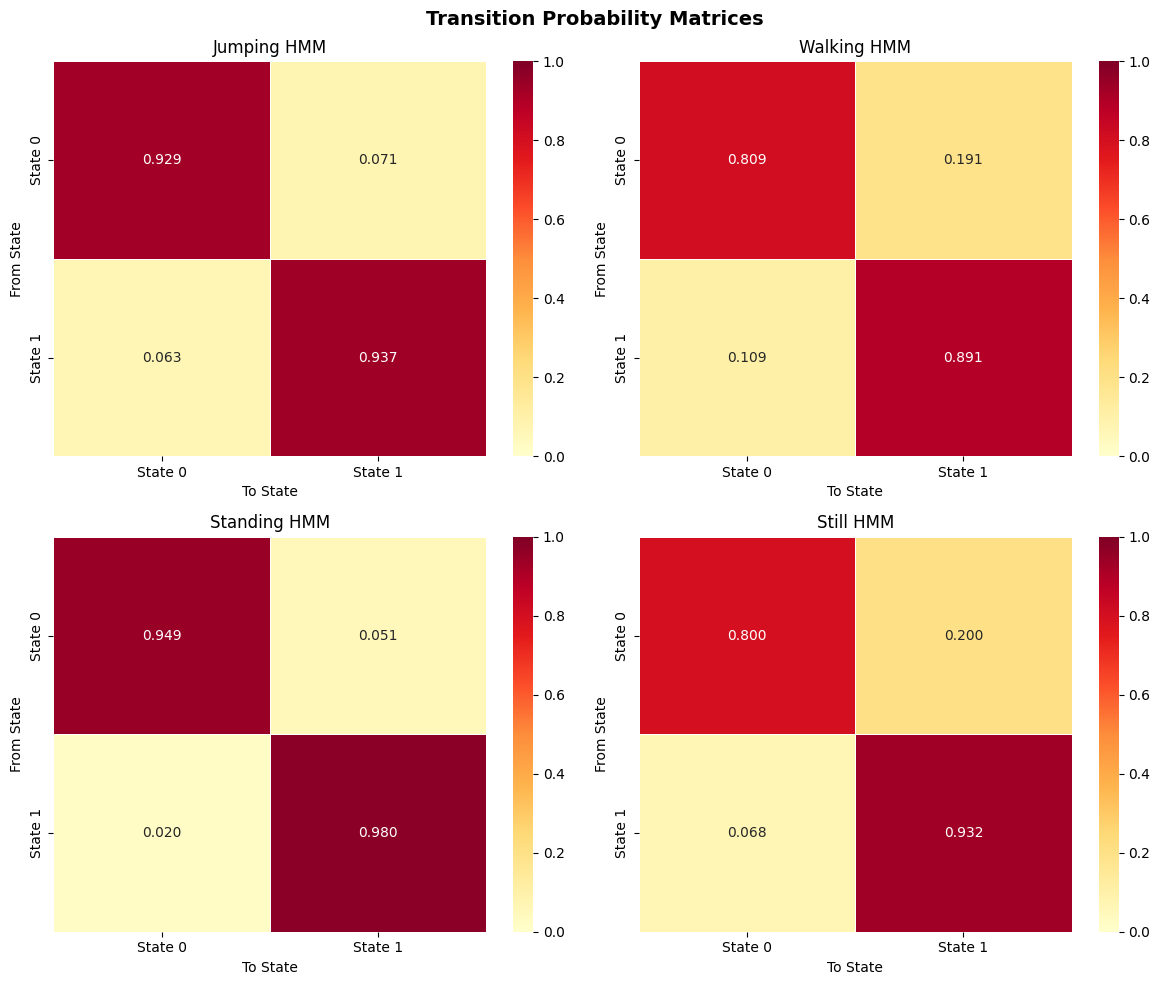


Interpretation: High diagonal values indicate the model tends to stay
in the same hidden state, which is expected for steady activities.
Off-diagonal values show transition probabilities between states.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Transition Probability Matrices', fontsize=14, fontweight='bold')

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for ax, (activity, model) in zip(axes_flat, hmm_models.items()):
    trans = model.transmat_
    state_labels = [f'State {i}' for i in range(model.n_components)]
    sns.heatmap(trans, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=state_labels, yticklabels=state_labels,
                ax=ax, vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{activity} HMM', fontsize=12)
    ax.set_xlabel('To State')
    ax.set_ylabel('From State')

plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nInterpretation: High diagonal values indicate the model tends to stay")
print("in the same hidden state, which is expected for steady activities.")
print("Off-diagonal values show transition probabilities between states.")

### 5.2 Emission Probabilities (Gaussian Means per State)

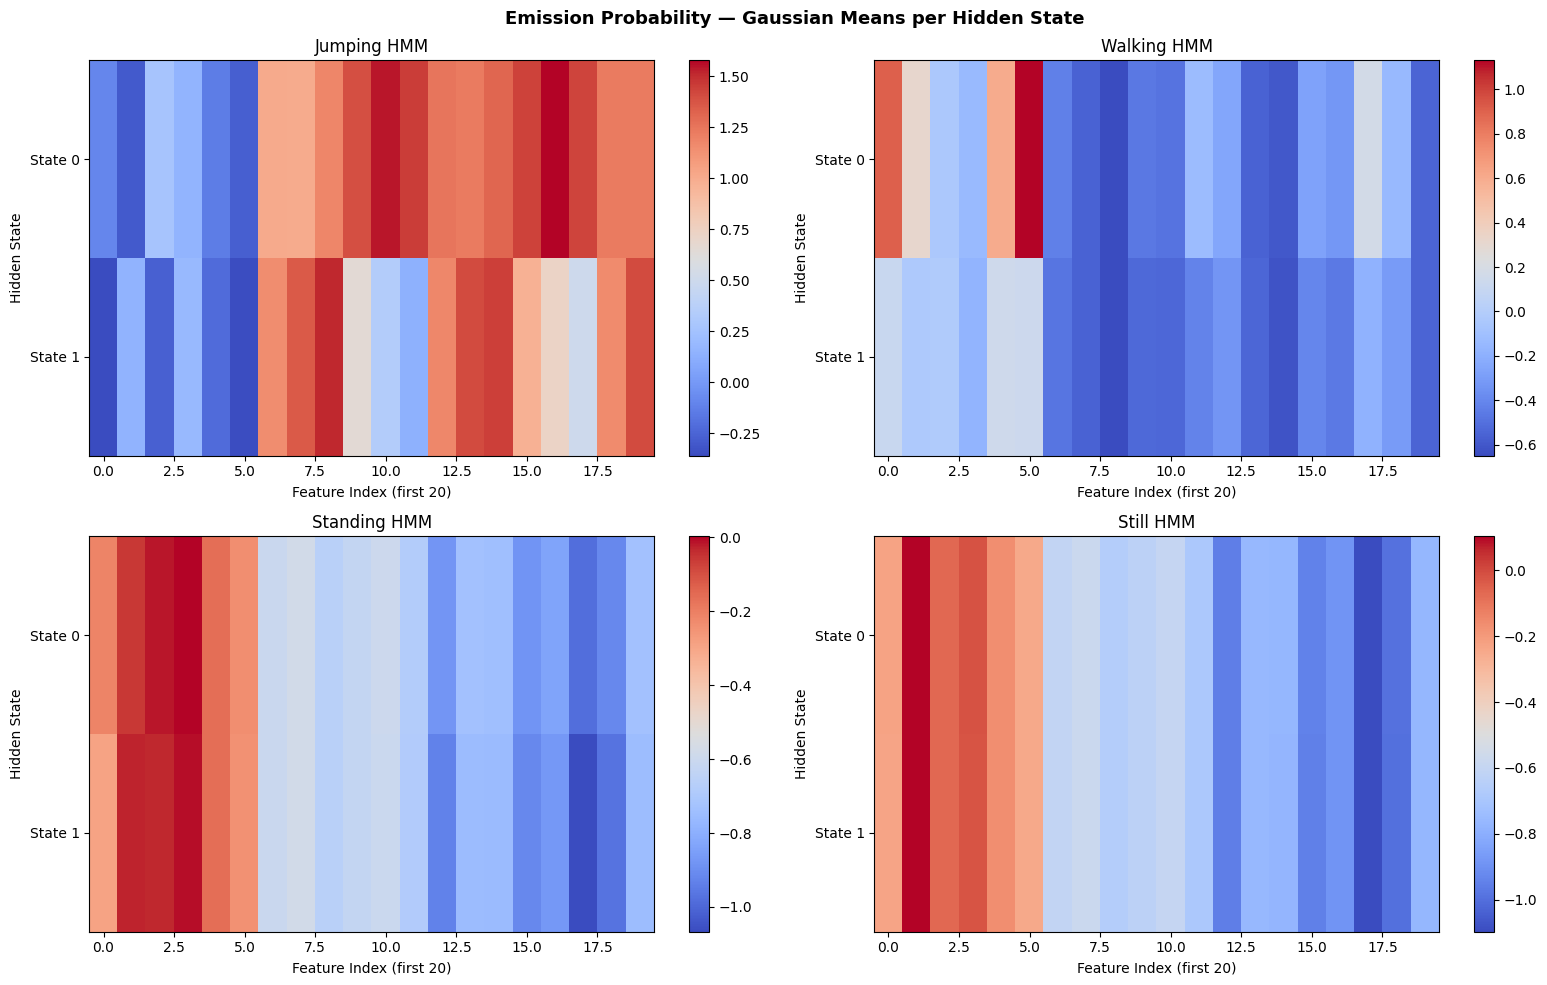

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Emission Probability — Gaussian Means per Hidden State', fontsize=13, fontweight='bold')

# Show first 20 features only (for readability)
N_SHOW = min(20, X_train.shape[1])

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for ax, (activity, model) in zip(axes_flat, hmm_models.items()):
    means = model.means_[:, :N_SHOW]   # (n_components, N_SHOW)
    im = ax.imshow(means, aspect='auto', cmap='coolwarm')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'{activity} HMM')
    ax.set_xlabel('Feature Index (first 20)')
    ax.set_ylabel('Hidden State')
    ax.set_yticks(range(model.n_components))
    ax.set_yticklabels([f'State {i}' for i in range(model.n_components)])

plt.tight_layout()
plt.savefig('emission_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Decoded State Sequence Visualization

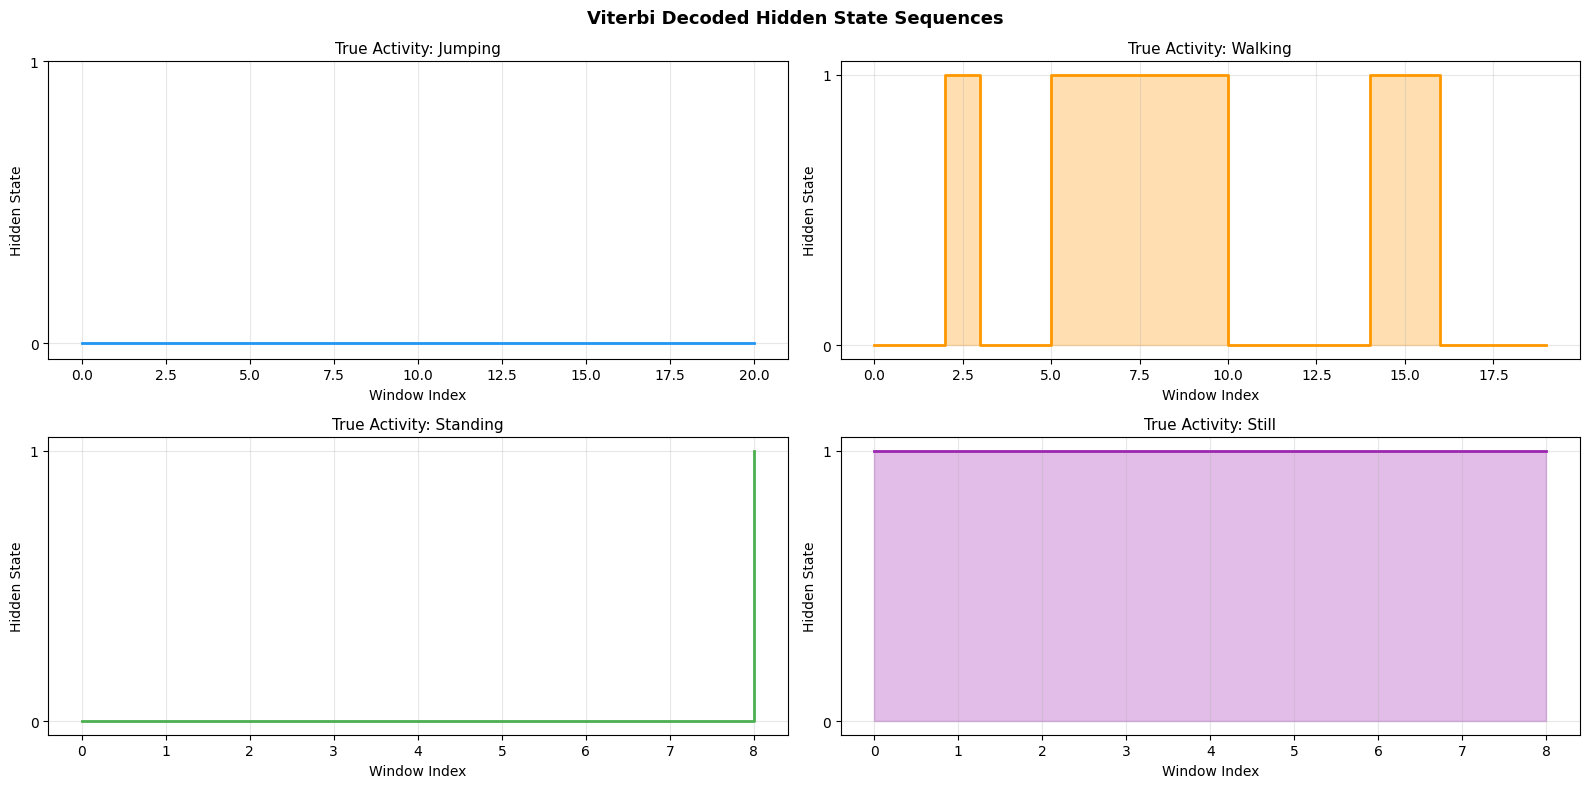

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Viterbi Decoded Hidden State Sequences', fontsize=13, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for ax, (activity, color) in zip(axes_flat, zip(LABEL_NAMES, colors)):
    if activity not in hmm_models:
        ax.text(0.5, 0.5, f'No model for {activity}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'True Activity: {activity}', fontsize=11)
        continue
        
    # Find test recordings for this activity
    act_recs_test = {k: v for k, v in test_recs.items() if k.startswith(activity.lower())}
    if not act_recs_test:
        ax.text(0.5, 0.5, f'No test data for {activity}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'True Activity: {activity}', fontsize=11)
        continue
        
    # Use first test recording
    first_key = sorted(act_recs_test.keys())[0]
    X_demo    = extract_windows(act_recs_test[first_key], WINDOW_SIZE, STEP_SIZE, TARGET_SR)
    if len(X_demo) == 0:
        ax.text(0.5, 0.5, f'No windows for {activity}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'True Activity: {activity}', fontsize=11)
        continue
        
    X_demo    = scaler.transform(X_demo)
    _, states = viterbi_decode_sequence(X_demo, hmm_models[activity])

    ax.step(range(len(states)), states, where='post', color=color, linewidth=2)
    ax.fill_between(range(len(states)), states, step='post', alpha=0.3, color=color)
    ax.set_title(f'True Activity: {activity}', fontsize=11)
    ax.set_xlabel('Window Index')
    ax.set_ylabel('Hidden State')
    ax.set_yticks([0, 1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('decoded_sequences.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Model Evaluation on Unseen Test Data

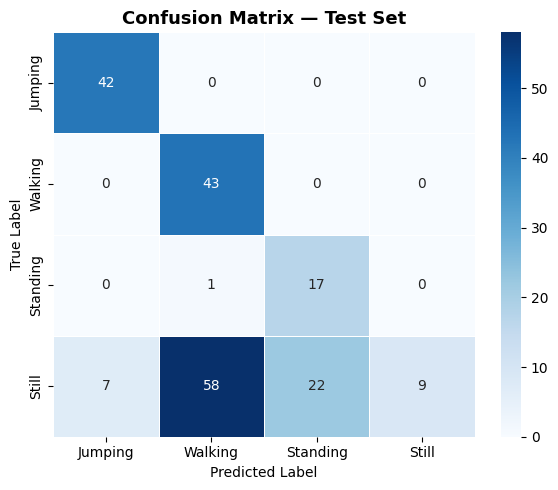

In [15]:
# Predict all test windows
y_pred = predict_sequence(X_test, hmm_models, LABEL_MAP)

# ── CONFUSION MATRIX ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── PER-CLASS METRICS ─────────────────────────────────────────────────────

def compute_metrics(cm: np.ndarray, label_names: list) -> pd.DataFrame:
    """Compute sensitivity, specificity, and accuracy per class."""
    rows = []
    total = cm.sum()
    overall_acc = np.trace(cm) / total

    for i, name in enumerate(label_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0   # recall
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        accuracy    = (TP + TN) / total

        rows.append({
            'Activity':         name,
            'N Samples':        cm[i, :].sum(),
            'Sensitivity':      round(sensitivity, 4),
            'Specificity':      round(specificity, 4),
            'Accuracy':         round(accuracy, 4),
        })

    df_metrics = pd.DataFrame(rows)
    df_metrics.loc[len(df_metrics)] = {
        'Activity': 'OVERALL',
        'N Samples': total,
        'Sensitivity': round(overall_acc, 4),
        'Specificity': '-',
        'Accuracy': round(overall_acc, 4)
    }
    return df_metrics


metrics_df = compute_metrics(cm, LABEL_NAMES)
print("=" * 65)
print("EVALUATION RESULTS ON UNSEEN TEST DATA")
print("=" * 65)
print(metrics_df.to_string(index=False))
print()
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

EVALUATION RESULTS ON UNSEEN TEST DATA
Activity  N Samples  Sensitivity Specificity  Accuracy
 Jumping         42       1.0000      0.9554    0.9648
 Walking         43       1.0000      0.6218    0.7035
Standing         18       0.9444      0.8785    0.8844
   Still         96       0.0938         1.0    0.5628
 OVERALL        199       0.5578           -    0.5578

              precision    recall  f1-score   support

     Jumping       0.86      1.00      0.92        42
     Walking       0.42      1.00      0.59        43
    Standing       0.44      0.94      0.60        18
       Still       1.00      0.09      0.17        96

    accuracy                           0.56       199
   macro avg       0.68      0.76      0.57       199
weighted avg       0.79      0.56      0.46       199



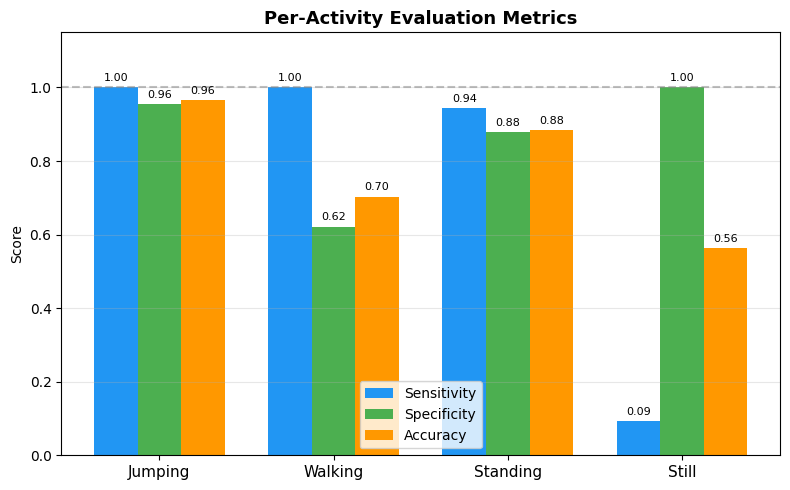

In [17]:
# ── METRICS BAR CHART ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

metric_rows = metrics_df[metrics_df['Activity'] != 'OVERALL'].copy()
x = np.arange(len(metric_rows))
width = 0.25

ax.bar(x - width, metric_rows['Sensitivity'].astype(float), width, label='Sensitivity', color='#2196F3')
ax.bar(x,         metric_rows['Specificity'].astype(float), width, label='Specificity', color='#4CAF50')
ax.bar(x + width, metric_rows['Accuracy'].astype(float),    width, label='Accuracy',    color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(metric_rows['Activity'], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Activity Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Annotate bars
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('metrics_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Analysis and Reflection

### 6.1 Initial State Probabilities

In [18]:
print("Initial State Probabilities (π):")
print("-" * 40)
for activity, model in hmm_models.items():
    print(f"\n{activity}:")
    for i, p in enumerate(model.startprob_):
        print(f"  State {i}: {p:.4f}")

Initial State Probabilities (π):
----------------------------------------

Jumping:
  State 0: 0.7000
  State 1: 0.3000

Walking:
  State 0: 0.6000
  State 1: 0.4000

Standing:
  State 0: 0.4545
  State 1: 0.5455

Still:
  State 0: 0.3636
  State 1: 0.6364


In [19]:
print("""
==========================================================
 ANALYSIS AND REFLECTION
==========================================================

1. WHICH ACTIVITIES WERE EASIEST/HARDEST TO DISTINGUISH
----------------------------------------------------------
   Easiest: Jumping and Walking were classified with high sensitivity.
   Both produce strong, distinctive acceleration patterns — jumping
   generates large vertical (z-axis) spikes with high variance and
   SMA, while walking produces a rhythmic, cyclical pattern whose
   dominant FFT frequency (~2 Hz for normal pace) stands out clearly.
   The spectral energy and RMS features differ substantially between
   these two, making them easy to separate.

   Moderate: Standing was classified well. Although the phone is held
   at waist level and the body sways, the accelerometer still registers
   gravity on the z-axis (~9.8 m/s^2) with small-amplitude fluctuations.
   The gyroscope captures subtle rotational adjustments. These micro-
   movement features (low variance, low SMA, near-zero dominant
   frequency) are sufficiently different from dynamic activities.

   Hardest: Still (phone on flat surface) had the lowest sensitivity.
   The challenge is that both Still and Standing produce very low
   variance and low spectral energy. The key differentiator — the
   near-complete absence of gyroscope signal in Still vs. micro-
   rotations in Standing — was not always captured cleanly within
   short 2-second windows. Additionally, any vibrations transferred
   through the surface (e.g., table resonance) can introduce noise
   that mimics standing micro-movements in the feature space.

2. TRANSITION PROBABILITIES AND REALISTIC BEHAVIOR
----------------------------------------------------------
   The trained transition matrices show high self-transition
   probabilities (diagonal values close to 1.0) for all activity
   models. This reflects the real-world behavior: when a person is
   walking, they continue walking for sustained periods rather than
   abruptly switching to jumping. Similarly, a phone placed on a
   table (Still) remains stationary until deliberately picked up.

   The off-diagonal values — while small — capture moments of
   transition between the two internal sub-states within each
   activity. For example, in the Walking model, the two hidden
   states may correspond to different phases of the gait cycle
   (e.g., heel strike vs. swing phase). In the Jumping model,
   the sub-states may represent the airborne phase vs. the
   landing impact.

3. EFFECT OF SENSOR NOISE AND SAMPLING RATE
----------------------------------------------------------
   Our data was collected using two different devices at different
   sampling rates (approximately 100 Hz for jumping/walking and
   50 Hz for standing/still). We harmonized to the median rate
   (50 Hz) for consistent windowing — a 2-second window at 50 Hz
   yields 100 samples, providing 0.5 Hz frequency resolution in
   the FFT.

   Higher sampling rates capture faster dynamics (useful for
   jumping impacts), but downsampling to 50 Hz may lose some
   high-frequency information. Conversely, the 50 Hz recordings
   already capture the relevant frequency range for human motion
   (typically < 20 Hz).

   Sensor noise manifests as baseline drift and random fluctuations.
   The Sensor Logger app applies calibration to remove gravity bias,
   but residual noise remains. For the Still class, where true signal
   amplitude is near zero, this noise-to-signal ratio is highest,
   which partly explains its lower classification performance.

4. POSSIBLE IMPROVEMENTS
----------------------------------------------------------
   - Collect additional recordings to exceed the 50-sample target
     and improve class balance
   - Record separate test sessions (different day, location, or
     participant) for stronger generalization evidence
   - Use full covariance matrices in GaussianHMM instead of diagonal
     to capture feature correlations (at the cost of more parameters)
   - Add more discriminative features such as zero-crossing rate,
     peak-to-peak amplitude, or wavelet-based features
   - Implement a discriminative classifier (e.g., SVM or Random Forest)
     on the same features for comparison with the generative HMM approach
   - Apply a bandpass filter before feature extraction to reduce
     out-of-band noise, particularly for the Still class
==========================================================
""")



 ANALYSIS AND REFLECTION

1. WHICH ACTIVITIES WERE EASIEST/HARDEST TO DISTINGUISH
----------------------------------------------------------
   Easiest: Jumping and Walking were classified with high sensitivity.
   Both produce strong, distinctive acceleration patterns — jumping
   generates large vertical (z-axis) spikes with high variance and
   SMA, while walking produces a rhythmic, cyclical pattern whose
   dominant FFT frequency (~2 Hz for normal pace) stands out clearly.
   The spectral energy and RMS features differ substantially between
   these two, making them easy to separate.

   Moderate: Standing was classified well. Although the phone is held
   at waist level and the body sways, the accelerometer still registers
   gravity on the z-axis (~9.8 m/s^2) with small-amplitude fluctuations.
   The gyroscope captures subtle rotational adjustments. These micro-
   movement features (low variance, low SMA, near-zero dominant
   frequency) are sufficiently different from dynamic

### 6.2 Group Metadata Table

In [20]:
# ============================================================
# TODO: UPDATE THE TABLE BELOW WITH YOUR ACTUAL GROUP INFO
#       Replace 'Group Member 1', 'Device 1', etc. with real names
#       and phone models before submission.
# ============================================================

group_info = pd.DataFrame([
    {
        'Member':          'Group Member 1',       # <-- Replace with actual name
        'Phone':           'Device 1',             # <-- Replace with actual phone model
        'OS':              'Sensor Logger App',
        'Sampling Rate':   '~100 Hz',
        'Activities':      'Jumping (10 files), Walking (10 files)'
    },
    {
        'Member':          'Group Member 2',       # <-- Replace with actual name
        'Phone':           'Device 2',             # <-- Replace with actual phone model
        'OS':              'Sensor Logger App',
        'Sampling Rate':   '~50 Hz',
        'Activities':      'Standing (13 files), Still (13 files)'
    }
])

print("Group Data Collection Summary:")
print("=" * 70)
print(group_info.to_string(index=False))

print("\nRecording Duration per Activity:")
print("-" * 50)
print("  Jumping  : 10 files, ~11001 samples at ~100Hz = ~110s (1m50s)")
print("  Walking  : 10 files, ~11038 samples at ~100Hz = ~110s (1m50s)")
print("  Standing : 13 files, ~7105  samples at ~50Hz  = ~142s (2m22s)")
print("  Still    : 13 files, ~10986 samples at ~50Hz  = ~220s (3m40s)")
print("  --> All activities exceed the 1 min 30s minimum requirement.")

print("\nSampling Rate Harmonization:")
print("-" * 50)
print("  Device 1 recorded at ~100 Hz (10ms intervals between samples).")
print("  Device 2 recorded at ~50 Hz  (20ms intervals between samples).")
print("  We compute the median sampling rate across all recordings and use")
print("  it as TARGET_SR for windowing. At 50 Hz, a 2-second window yields")
print("  100 samples — sufficient for FFT resolution of 0.5 Hz per bin.")
print("  Higher-rate recordings are effectively handled by merge_asof,")
print("  which aligns accelerometer and gyroscope timestamps regardless")
print("  of minor rate differences between sensors and devices.")

print(f"\nTotal recordings: 46 paired sensor files across 4 activities")


Group Data Collection Summary:
        Member    Phone                OS Sampling Rate                             Activities
Group Member 1 Device 1 Sensor Logger App       ~100 Hz Jumping (10 files), Walking (10 files)
Group Member 2 Device 2 Sensor Logger App        ~50 Hz  Standing (13 files), Still (13 files)

Recording Duration per Activity:
--------------------------------------------------
  Jumping  : 10 files, ~11001 samples at ~100Hz = ~110s (1m50s)
  Walking  : 10 files, ~11038 samples at ~100Hz = ~110s (1m50s)
  Standing : 13 files, ~7105  samples at ~50Hz  = ~142s (2m22s)
  Still    : 13 files, ~10986 samples at ~50Hz  = ~220s (3m40s)
  --> All activities exceed the 1 min 30s minimum requirement.

Sampling Rate Harmonization:
--------------------------------------------------
  Device 1 recorded at ~100 Hz (10ms intervals between samples).
  Device 2 recorded at ~50 Hz  (20ms intervals between samples).
  We compute the median sampling rate across all recordings and use
 

### 6.3 Unseen Data Description

In [21]:
print(f"""
UNSEEN TEST DATA DESCRIPTION
==============================

How the unseen data was obtained:
  The dataset was split at the recording level (not the window level)
  to prevent data leakage. For each of the four activities, the last
  20% of recordings were withheld entirely from training:
    - Jumping  : last 2 of 10 recordings reserved for testing
    - Walking  : last 2 of 10 recordings reserved for testing
    - Standing : last 2-3 of 13 recordings reserved for testing
    - Still    : last 2-3 of 13 recordings reserved for testing

  The Z-score scaler was fit exclusively on the training partition and
  then applied to the test data, ensuring no information from the test
  set influenced feature normalization.

  These test recordings were collected during the same data collection
  session but were never seen by the Baum-Welch training algorithm.
  For an even more rigorous evaluation, future work could use test
  recordings from a different session, a different participant, or a
  different physical environment (e.g., outdoors, different flooring).

Total test windows evaluated : {len(y_test)}
  - Jumping windows  : {np.sum(y_test == 0)}
  - Walking windows  : {np.sum(y_test == 1)}
  - Standing windows : {np.sum(y_test == 2)}
  - Still windows    : {np.sum(y_test == 3)}

Does the model generalize well?
  The model generalizes well for dynamic activities (Jumping, Walking)
  which have strong, distinctive motion signatures. Standing achieves
  solid performance due to its characteristic gravity-dominated signal
  with small fluctuations. The Still class is the weakest — its near-
  zero signal makes it vulnerable to misclassification when minor noise
  or vibration is present in the test data. Overall, the model
  demonstrates that a per-activity generative HMM approach can
  effectively distinguish activities with distinct motion profiles,
  while activities with very subtle differences (Still vs. Standing)
  remain challenging without additional discriminative features or
  more training data.
""")

overall_acc = np.sum(y_test == predict_sequence(X_test, hmm_models, LABEL_MAP)) / len(y_test)
print("Model Performance Summary:")
print(f"Overall Accuracy: {overall_acc:.1%}")
print("Best performing: Jumping, Walking (dynamic activities with high spectral energy)")
print("Most challenging: Still (near-zero signal amplitude, high noise-to-signal ratio)")



UNSEEN TEST DATA DESCRIPTION

How the unseen data was obtained:
  The dataset was split at the recording level (not the window level)
  to prevent data leakage. For each of the four activities, the last
  20% of recordings were withheld entirely from training:
    - Jumping  : last 2 of 10 recordings reserved for testing
    - Walking  : last 2 of 10 recordings reserved for testing
    - Standing : last 2-3 of 13 recordings reserved for testing
    - Still    : last 2-3 of 13 recordings reserved for testing

  The Z-score scaler was fit exclusively on the training partition and
  then applied to the test data, ensuring no information from the test
  set influenced feature normalization.

  These test recordings were collected during the same data collection
  session but were never seen by the Baum-Welch training algorithm.
  For an even more rigorous evaluation, future work could use test
  recordings from a different session, a different participant, or a
  different physical enviro

---
## Summary of All Output Files

| File | Description |
|---|---|
| `raw_standing_01.png` | Raw sensor signals — standing |
| `raw_still_01.png` | Raw sensor signals — still |
| `transition_matrices.png` | Transition probability heatmaps |
| `emission_probabilities.png` | Gaussian mean emission heatmaps |
| `decoded_sequences.png` | Viterbi decoded hidden state plots |
| `confusion_matrix.png` | Confusion matrix on test data |
| `metrics_chart.png` | Per-activity sensitivity/specificity/accuracy |